# Bài 3: Phân cụm dữ liệu hoa Iris bằng thuật toán K-Means
Sử dụng thuật toán học không giám sát K-Means để phân nhóm các loài hoa Iris dựa trên các đặc trưng hình thái.

### 1. Khai báo thư viện và nạp dữ liệu
Chúng ta sử dụng thư viện `scikit-learn` để thực hiện thuật toán K-Means và `matplotlib/seaborn` để trực quan hóa kết quả.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

# Nạp bộ dữ liệu Iris chuẩn
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Chúng ta chỉ lấy dữ liệu (không lấy nhãn có sẵn) để thực hiện học không giám sát
X = iris.data 

print("Thông tin dữ liệu:")
print(df.info())
df.head()

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 2. Xác định số cụm tối ưu (Phương pháp Elbow)
Chúng ta tính toán lỗi SSE (Sum of Squared Errors) để chọn số cụm `k` phù hợp nhất. Điểm "khuỷu tay" (Elbow) là giá trị k lý tưởng.

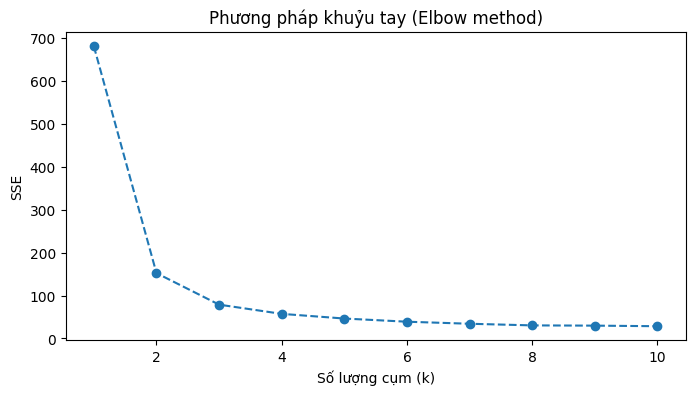

In [2]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.title('Phương pháp khuỷu tay (Elbow method)')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('SSE')
plt.show()

### 3. Huấn luyện mô hình với k = 3
Dựa trên kiến thức về loài hoa Iris (thường có 3 loại), chúng ta chọn số cụm là 3 để phân chia dữ liệu ban đầu.

In [3]:
# Khởi tạo mô hình K-Means với 3 cụm
kmeans_model = KMeans(n_clusters=3, n_init='auto', random_state=42)
y_kmeans = kmeans_model.fit_predict(X)

# Thêm kết quả phân cụm vào DataFrame ban đầu
df['Cluster'] = y_kmeans
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


### 4. Trực quan hóa kết quả phân cụm
Sử dụng biểu đồ tán xạ (Scatter Plot) để quan sát sự phân bố các cụm sau khi mô hình đã phân loại. Các ngôi sao màu vàng là tâm (Centroids) của mỗi cụm.

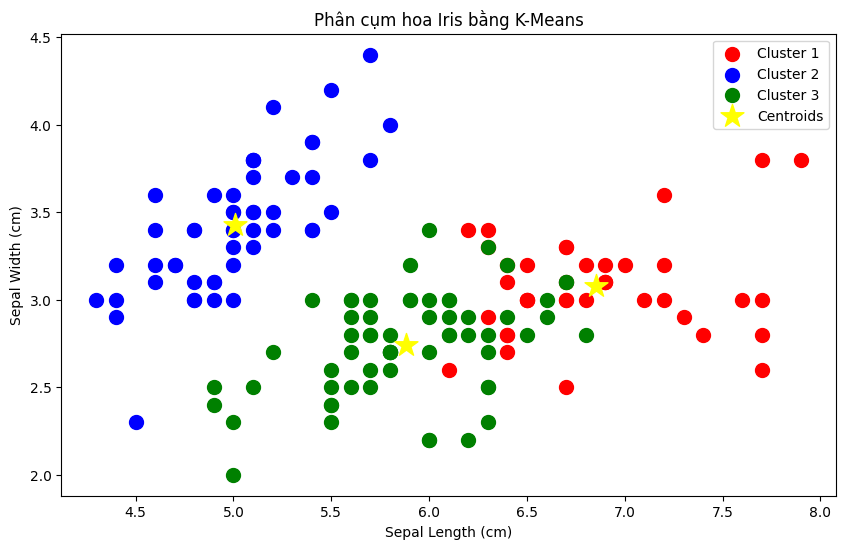

In [4]:
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu theo cụm
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')

# Vẽ các tâm cụm (Centroids)
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], 
            s=300, c='yellow', label='Centroids', marker='*')

plt.title('Phân cụm hoa Iris bằng K-Means')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()